In [1]:
import pandas as pd
from sqlalchemy import create_engine
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import numpy as np
import platform
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
import statsmodels.api as sm
import ssl
import certifi
from urllib.request import urlopen
import json
from DATA.stock_invest_function import *
import seaborn as sns
import matplotlib.pyplot as pl

In [2]:
def preprocess_quarterly_growth(df: pd.DataFrame) -> pd.DataFrame:
    """
    월별 데이터를 분기별로 집계하고, 전년 동분기 대비 성장률을 계산하는 함수
    """
    df['quarter'] = df['date'].dt.to_period('Q')
    df_quarterly = (
        df.groupby(['root_hs_code', 'quarter'])['value']
          .sum()
          .reset_index()
    )
    df_quarterly['date'] = df_quarterly['quarter'].dt.to_timestamp(how='end')
    df_quarterly.drop(columns=['quarter'], inplace=True)
    df_quarterly['date'] = pd.to_datetime(df_quarterly['date']).dt.date

    df_quarterly = df_quarterly.sort_values(['root_hs_code', 'date'])
    df_quarterly['yoy_value'] = df_quarterly.groupby('root_hs_code')['value'].shift(4)
    df_quarterly['yoy_growth'] = (
        (df_quarterly['value'] - df_quarterly['yoy_value']) / df_quarterly['yoy_value']
    ) * 100

    return df_quarterly


def create_yoy_growth_pivot(df_quarterly: pd.DataFrame,
                             start_date: str = None,
                             end_date: str = None) -> pd.DataFrame:
    """
    전년 동분기 대비 증가율을 pivot 형태로 변환하고 분석기간을 설정할 수 있는 함수
    
    Parameters:
    - df_quarterly (DataFrame): 'root_hs_code', 'date', 'yoy_growth' 포함된 데이터
    - start_date (str or None): 분석 시작일 (예: '2015-01-01')
    - end_date (str or None): 분석 종료일 (예: '2023-12-31')

    Returns:
    - pivot_df (DataFrame): 행: date, 열: root_hs_code, 값: yoy_growth
    """
    pivot_df = df_quarterly.pivot(
        index='date',
        columns='root_hs_code',
        values='yoy_growth'
    ).sort_index()

    pivot_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    pivot_df.index = pd.to_datetime(pivot_df.index)

    if start_date:
        pivot_df = pivot_df[pivot_df.index >= pd.to_datetime(start_date)]
    if end_date:
        pivot_df = pivot_df[pivot_df.index <= pd.to_datetime(end_date)]

    return pivot_df

def pivot_dataframe(df, index_col='date', column_col='root_hs_code',
                    indicator_col='indicator', value_col='value', indicator_value='expDlr'):
    """
    주어진 DataFrame에서 특정 indicator 값에 해당하는 데이터를 필터링하여
    pivot table을 생성합니다.

    Parameters:
    - df: 원본 DataFrame
    - index_col: 피벗 테이블의 인덱스가 될 열 (기본값 'date')
    - column_col: 피벗 테이블의 칼럼이 될 열 (기본값 'root_hs_code')
    - indicator_col: 필터링에 사용할 indicator 열 (기본값 'indicator')
    - value_col: 피벗 테이블의 값이 될 열 (기본값 'value')
    - indicator_value: 사용할 indicator 값 (기본값 'expDlr')

    Returns:
    - pivot_df: 피벗 테이블 형태의 DataFrame
    """
    # indicator 기준 필터링
    filtered_df = df[df[indicator_col] == indicator_value].copy()

    # 피벗 테이블 생성
    pivot_df = filtered_df.pivot(index=index_col,
                                 columns=column_col,
                                 values=value_col)

    return pivot_df

def analyze_export_trends(pivot_df, n_recent=12, n_top=5):
    """
    수출금액 피벗 테이블을 기반으로 고점 돌파 HS Code와
    YoY 증가율 상위 HS Code를 추출하는 함수.

    inf 값은 자동으로 제외됩니다.

    Parameters:
    - pivot_df: date-indexed, hs_code-columned DataFrame (value = 수출금액)
    - n_recent: 최근 몇 개월을 기준으로 분석할지 (기본값: 12개월)
    - n_top: 상위 몇 종목을 출력할지 (기본값: 5종목)

    Returns:
    - breakout_codes: 신고점을 갱신한 HS Code 리스트
    - top_yoy_growth_df: 최근 n개월간 YoY 증가율 상위 n개 HS Code의 DataFrame
    """

    # 날짜 기준 정렬
    pivot_df = pivot_df.sort_index()

    # 최근 n개월 데이터 선택
    recent_df = pivot_df.iloc[-n_recent:]
    last_month = recent_df.index[-1]

    # 1. 신고점 돌파한 HS Code 찾기
    breakout_codes = []
    for col in recent_df.columns:
        max_before = recent_df.iloc[:-1][col].max()
        last_value = recent_df.iloc[-1][col]
        if pd.notna(last_value) and last_value > max_before:
            breakout_codes.append(col)

    # 2. 최근 n개월간 YoY 증가율 계산
    yoy_df = pivot_df.copy()
    yoy_df.index = pd.to_datetime(yoy_df.index)

    # 12개월 전 대비 YoY 변화율 (%)
    yoy_change = yoy_df.pct_change(12) * 100
    recent_yoy = yoy_change.iloc[-n_recent:]

    # 평균 YoY 성장률 계산
    mean_yoy_growth = recent_yoy.mean()

    # inf, -inf, NaN 제거
    mean_yoy_growth = mean_yoy_growth.replace([np.inf, -np.inf], np.nan).dropna()

    # 상위 n개 종목 추출
    top_yoy_growth_df = mean_yoy_growth.sort_values(ascending=False).head(n_top).reset_index()
    top_yoy_growth_df.columns = ['HS_Code', f'Mean_YoY_Growth_{n_recent}m (%)']

       # 보기 좋게 숫자 포맷팅 (소수점 2자리까지)
    colname = f'Mean_YoY_Growth_{n_recent}m (%)'
    top_yoy_growth_df[colname] = top_yoy_growth_df[colname].round(2)

    return breakout_codes, top_yoy_growth_df


def get_recent_yoy_growth(pivot_df, hs_code, n_recent=12):
    """
    특정 HS Code의 최근 n개월 YoY 수출 증가율(%)을 반환하는 함수

    Parameters:
    - pivot_df: date-indexed, hs_code-columned DataFrame (수출금액 피벗 테이블)
    - hs_code: 조회할 HS 코드 (문자열 또는 정수형)
    - n_recent: 최근 몇 개월치를 조회할지 (기본값: 12)

    Returns:
    - pandas.Series: 최근 n개월간 날짜별 YoY 증가율 (소수 둘째 자리 반올림)
    """
    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)

    if hs_code not in df.columns:
        raise ValueError(f"HS Code '{hs_code}'가 데이터에 없습니다.")

    # 해당 HS Code만 추출
    ts = df[hs_code]

    # YoY 변화율 계산 (%)
    yoy = ts.pct_change(12) * 100

    # 최근 n개월 가져오기
    recent_yoy = yoy.dropna().iloc[-n_recent:]

    # 소수 둘째 자리까지 반올림
    return recent_yoy.round(2)

def find_ma_golden_cross(pivot_df):
    """
    HS Code별로 3/6/12개월 이동평균을 계산하고,
    3-6개월, 3-12개월 골든크로스를 만족하는 HS Code를 반환합니다.

    Parameters:
    - pivot_df: 날짜 인덱스(date), HS Code를 열로 가진 수출금액 피벗 테이블

    Returns:
    - cross_3_6: 3개월 > 6개월 골든크로스 조건을 만족하는 HS Code 리스트
    - cross_3_12: 3개월 > 12개월 골든크로스 조건을 만족하는 HS Code 리스트
    """

    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    # 이동평균 계산
    ma_3 = df.rolling(window=3).mean()
    ma_6 = df.rolling(window=6).mean()
    ma_12 = df.rolling(window=12).mean()

    # 최근 시점 (마지막 row) 기준 비교
    latest_ma_3 = ma_3.iloc[-1]
    latest_ma_6 = ma_6.iloc[-1]
    latest_ma_12 = ma_12.iloc[-1]

    # 골든크로스 조건 필터링
    cross_3_6 = latest_ma_3[latest_ma_3 > latest_ma_6].dropna().index.tolist()
    cross_3_12 = latest_ma_3[latest_ma_3 > latest_ma_12].dropna().index.tolist()

    return cross_3_6, cross_3_12

def plot_export_with_moving_averages(pivot_df, hs_code, start_date=None):
    """
    특정 HS Code의 수출금액과 3, 6, 12개월 이동평균선을 시각화하는 함수

    Parameters:
    - pivot_df: 날짜 인덱스를 가진 HS Code별 수출금액 피벗 테이블
    - hs_code: 시각화할 HS Code (문자열 또는 정수)
    - start_date: 시각화 시작 시점 (문자열 'YYYY-MM-DD' 또는 None)
    """

    df = pivot_df.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    if hs_code not in df.columns:
        raise ValueError(f"HS Code '{hs_code}'는 데이터에 없습니다.")

    series = df[hs_code]

    # 이동평균 계산
    ma_3 = series.rolling(3).mean()
    ma_6 = series.rolling(6).mean()
    ma_12 = series.rolling(12).mean()

    # 시각화 구간 자르기 (선택사항)
    if start_date:
        series = series[series.index >= start_date]
        ma_3 = ma_3[ma_3.index >= start_date]
        ma_6 = ma_6[ma_6.index >= start_date]
        ma_12 = ma_12[ma_12.index >= start_date]

    # 시각화
    plt.figure(figsize=(12, 6))
    plt.plot(series, label='Monthly Export', color='black', linewidth=2)
    plt.plot(ma_3, label='3-Month MA', linestyle='--')
    plt.plot(ma_6, label='6-Month MA', linestyle='--')
    plt.plot(ma_12, label='12-Month MA', linestyle='--')

    plt.title(f'Export Trend for HS Code {hs_code}', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Export Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_forecast_by_hscode_list(db_info, hs_code_list, table_name='korea_monthly_trade_data_forecast'):
    for hs_code in hs_code_list:
        # 데이터 불러오기
        temp_df = load_forecast_by_hscode(db_info, hs_code, table_name=table_name)

        # 유효성 검사: 데이터가 없으면 스킵
        if temp_df is None or temp_df.empty:
            print(f"⚠️ HS Code {hs_code}: 데이터가 없습니다. 건너뜁니다.")
            continue

        # index를 date로 설정
        df_plot = temp_df.set_index('date')[['expDlr_forecast_12m']]

        # 메인 라인: 전체 구간 파란색
        df_plot.plot(color='skyblue', label='expDlr_forecast_12m')

        # 마지막 12개 데이터 분리
        last_12 = df_plot.tail(12)

        # 마지막 12개를 오렌지 점선으로
        plt.plot(last_12.index, last_12['expDlr_forecast_12m'],
                 linestyle='--', color='orange', label='last 12')

        # 범례, 타이틀, 그리드
        plt.legend()
        plt.title(f"HS Code {hs_code} Forecast")
        plt.grid(True)
        plt.show()

In [3]:
# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우 기본 한글 폰트
elif platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
else:  # Linux (예: Google Colab)
    plt.rc('font', family='NanumGothic')

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# info_path =r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA\hs_code_description.csv"
# # 방법 1: CP949 인코딩 사용
# hs_codes_info = pd.read_csv(info_path, encoding='cp949')
# hs_codes_info['hs_code'] = hs_codes_info['hs_code'].astype('str')
# hs_codes_info.head(3)

In [5]:
db_info = {
    'host': get_db_host(),
    # 'host' : 'hystox74.synology.me',
    'port': 3307,
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'database': 'investar'
}

# SQLAlchemy 엔진 생성
engine = create_engine(
    f"mysql+pymysql://{db_info['user']}:{db_info['password']}@{db_info['host']}:{db_info['port']}/{db_info['database']}"
)

# 테이블 이름
table_name = 'target_hs_code'

# 고유한 hs_code 값 추출 쿼리 실행
query = f"SELECT DISTINCT hs_code FROM {table_name}"
unique_hs_codes_df = pd.read_sql(query, con=engine)
hs_codes  = unique_hs_codes_df['hs_code'].unique().tolist()

indicator = 'expDlr'

df_real = fetch_trade_data_multi_hscode(db_info, hs_codes, indicator)
trade_data_df = fetch_table_data(db_info, "korea_monthly_trade_data")

✅ 'korea_monthly_trade_data' 테이블에서 788650건의 데이터를 가져왔습니다.


In [6]:
trade_pivot_df = pivot_dataframe(trade_data_df,
                 index_col='date',
                 column_col='root_hs_code',
                 indicator_col='indicator',
                 value_col='value',
                 indicator_value='expDlr')

print(trade_pivot_df.tail())

root_hs_code     121120        1212      121221     151550    151590  \
date                                                                   
2025-02-28    6011720.0  55237400.0  55165200.0  1246120.0  660463.0   
2025-03-31    7055100.0  52757000.0  52688500.0  1117140.0  469246.0   
2025-04-30    4971210.0  58768000.0  58869200.0  1023190.0  412422.0   
2025-05-31    6048480.0  52621000.0  52523300.0  1477300.0  455672.0   
2025-06-30    5780780.0  52982800.0  52916200.0        NaN       NaN   

root_hs_code        1518      170199         1902       190230        1905  \
date                                                                         
2025-02-28    15542700.0   6475060.0  140374000.0  129400000.0  37741300.0   
2025-03-31    22174600.0   7257740.0  137973000.0  126553000.0  36688300.0   
2025-04-30    29367600.0   8785180.0  159705000.0  147972000.0  44714300.0   
2025-05-31    26819300.0   7785650.0  148610000.0  138175000.0  35908200.0   
2025-06-30    29932900.0  1

In [7]:
trade_pivot_df.tail(10)

root_hs_code,121120,1212,121221,151550,151590,1518,170199,1902,190230,1905,...,903289,9301,9306,9401,940130,940199,940330,940540,950300,970191
date,,,,,,,,,,,,,,,,,,,,,
2024-09-30,5040410.0,22989000.0,22830800.0,1154310.0,576487.0,16692000.0,18878600.0,121075000.0,111869000.0,35344200.0,...,73802400.0,150229000.0,267633000.0,68083400.0,NaN,63501300.0,1682660.0,NaN,6412440.0,35002100.0
2024-10-31,7251100.0,29038600.0,29008500.0,1128820.0,610214.0,9389900.0,18439300.0,136032000.0,126251000.0,41846500.0,...,67494300.0,146632000.0,39196200.0,79828800.0,NaN,74779900.0,629052.0,NaN,9831590.0,38237000.0
2024-11-30,5865170.0,23775100.0,23745000.0,1696580.0,495173.0,2706900.0,19223600.0,136311000.0,126269000.0,39605400.0,...,70544600.0,132167000.0,52069400.0,72180300.0,NaN,64976900.0,918416.0,NaN,6804360.0,8015870.0
2024-12-31,14434200.0,31104600.0,31044300.0,1147750.0,509171.0,20298500.0,17120600.0,127971000.0,118456000.0,38641800.0,...,70544400.0,126251000.0,146465000.0,65164700.0,NaN,60063500.0,872332.0,NaN,10314300.0,9780610.0
2025-01-31,4952300.0,44219200.0,44145700.0,1099810.0,412448.0,31609300.0,6077960.0,123135000.0,114540000.0,32022600.0,...,63686400.0,94190300.0,33219800.0,55604100.0,NaN,50604000.0,694242.0,NaN,4597520.0,11238300.0
2025-02-28,6011720.0,55237400.0,55165200.0,1246120.0,660463.0,15542700.0,6475060.0,140374000.0,129400000.0,37741300.0,...,74380500.0,89685000.0,184755000.0,65669400.0,NaN,60894600.0,1151360.0,NaN,6382200.0,13075200.0
2025-03-31,7055100.0,52757000.0,52688500.0,1117140.0,469246.0,22174600.0,7257740.0,137973000.0,126553000.0,36688300.0,...,74196000.0,93625700.0,11050200.0,73788200.0,NaN,68313100.0,1004640.0,NaN,5755400.0,13468200.0
2025-04-30,4971210.0,58768000.0,58869200.0,1023190.0,412422.0,29367600.0,8785180.0,159705000.0,147972000.0,44714300.0,...,79089400.0,92580100.0,232702000.0,73967400.0,NaN,68863600.0,1274240.0,NaN,7135420.0,37093900.0
2025-05-31,6048480.0,52621000.0,52523300.0,1477300.0,455672.0,26819300.0,7785650.0,148610000.0,138175000.0,35908200.0,...,74749000.0,107357000.0,161727000.0,70148100.0,NaN,65753200.0,632820.0,NaN,5532190.0,19823800.0


In [8]:
# pivot_df = pivot_dataframe(...)  # 앞서 만든 피벗 테이블 함수로 만든 데이터프레임
num = 200
breakouts, yoy_top = analyze_export_trends(trade_pivot_df, n_recent=12, n_top=num)

print("신고점 돌파 종목 (HS Code):", breakouts)
print(f"\n최근 12개월 YoY 증가율 상위 {num}개 종목:")
print(yoy_top)

신고점 돌파 종목 (HS Code): ['2103', '210390', '2841', '284190', '2933', '3002', '300215', '3207', '320730', '330420', '3305', '330590', '3818', '381800', '3918', '391810', '4202', '7108', '710813', '7110', '711292', '722592', '730729', '7404', '740400', '760711', '790112', '8408', '840810', '8413', '841370', '8458', '845811', '845891', '8486', '848690', '8504', '850423', '850450', '8532', '853224', '8535', '853529', '853690', '8542', '854232', '854449', '870193', '870324', '870340', '8704', '870421', '870870', '900130', '9018', '901819', '901890', '9022', '902214', '902290', '903090', '903190', '903289']

최근 12개월 YoY 증가율 상위 200개 종목:
    HS_Code  Mean_YoY_Growth_12m (%)
0    840130              20615166.96
1    294130                167744.16
2    282520                 94065.12
3      7114                  4816.60
4      8802                  2540.52
..      ...                      ...
195  740721                    12.26
196  390290                    12.21
197  490199                    1

In [9]:
yoy_top

,HS_Code,Mean_YoY_Growth_12m (%)
0,840130,20615166.96
1,294130,167744.16
2,282520,94065.12
3,7114,4816.60
4,8802,2540.52
...,...,...
195,740721,12.26
196,390290,12.21
197,490199,12.18
198,854290,12.13


✅ root_hs_code=903082에 해당하는 235개 행을 불러왔습니다.


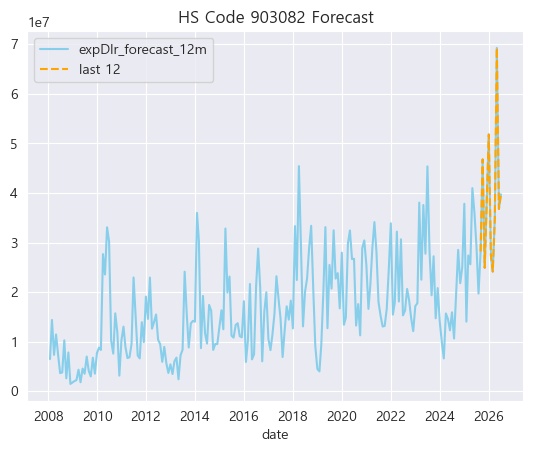

In [10]:
plot_forecast_by_hscode_list(db_info, ['903082'])

In [11]:
result = get_recent_yoy_growth(trade_pivot_df, hs_code='854232', n_recent=12)
print(result)

date
2024-07-31    90.18
2024-08-31    61.92
2024-09-30    62.38
2024-10-31    65.86
2024-11-30    51.23
2024-12-31    40.06
2025-01-31     5.05
2025-02-28    -8.71
2025-03-31    16.11
2025-04-30    17.65
2025-05-31    28.40
2025-06-30    16.66
Name: 854232, dtype: float64


In [12]:
# pivot_df: date index, HS Code columns, value = export amount
cross_3_6, cross_3_12 = find_ma_golden_cross(trade_pivot_df)

print("📈 3개월 > 6개월 이동평균 골든크로스 종목:")
print(cross_3_6)

print("\n📈 3개월 > 12개월 이동평균 골든크로스 종목:")
print(cross_3_12)

📈 3개월 > 6개월 이동평균 골든크로스 종목:
['1212', '121221', '1518', '170199', '1902', '190230', '1905', '190590', '2008', '200899', '210111', '2103', '210390', '2106', '210690', '2202', '220299', '2402', '240220', '2404', '270799', '2710', '271019', '2711', '271113', '271119', '2713', '271320', '2815', '281512', '281520', '2825', '282520', '283711', '2841', '284190', '290122', '290124', '290315', '290516', '290539', '2907', '290723', '2929', '292910', '293190', '2933', '293399', '2934', '293499', '294190', '3002', '300212', '300215', '300249', '3004', '300490', '320490', '3207', '320730', '3208', '320890', '3304', '330410', '330420', '330499', '3305', '330510', '330590', '3307', '330790', '3401', '340130', '3402', '3506', '350610', '350691', '3808', '380891', '381239', '381400', '3818', '381800', '390120', '390190', '3902', '390210', '390319', '390730', '390769', '390799', '3909', '390931', '391000', '3912', '391239', '3917', '3918', '391810', '3919', '391910', '391990', '3920', '392010', '392020', 

In [13]:
cross_both = list(set(cross_3_6) & set(cross_3_12))
print("\n📈 3개월 > 6개월 & 3개월 > 12개월 골든크로스 종목:")
print(cross_both)


📈 3개월 > 6개월 & 3개월 > 12개월 골든크로스 종목:
['3304', '720838', '7410', '903082', '6309', '220299', '741011', '3305', '7411', '845811', '8458', '330510', '850423', '381239', '392310', '4202', '720916', '740311', '740721', '845899', '842211', '391910', '854129', '721710', '843041', '853650', '854231', '210111', '890120', '7110', '722592', '8542', '8419', '722020', '853669', '722599', '3917', '8703', '330410', '680421', '490199', '9022', '350610', '870380', '848630', '903090', '600410', '3004', '540792', '6217', '853529', '870870', '7228', '852589', '2008', '3912', '841360', '7305', '870322', '121221', '842139', '9027', '722300', '730512', '847330', '390190', '7312', '848620', '390730', '842199', '390120', '8413', '8544', '902790', '848120', '841221', '740811', '850440', '740819', '300215', '6109', '8408', '630900', '760711', '2929', '901320', '722830', '3002', '870894', '7606', '3921', '903289', '870323', '870829', '720918', '2815', '690919', '8457', '8402', '740911', '851220', '902219', '8422',

In [14]:
# for hs_code in breakouts:
#     info = hs_codes_info[hs_codes_info['hs_code'] ==hs_code]
#     plot_export_with_moving_averages(trade_pivot_df, hs_code= hs_code, start_date='2018-01-01')
#     print(info)

In [15]:
# for hs_code in cross_both:
#     info = hs_codes_info[hs_codes_info['hs_code'] ==hs_code]
#     plot_export_with_moving_averages(trade_pivot_df, hs_code= hs_code, start_date='2018-01-01')
#     print(info)

#### 수출 전망치 조회

In [16]:
# hs_code = '630710'
# temp_df = load_forecast_by_hscode(db_info, hs_code, table_name='korea_monthly_trade_data_forecast')
#
# # index를 date로 설정
# df_plot = temp_df.set_index('date')[['expDlr_forecast_12m']]
#
# # 메인 라인: 전체 구간 파란색
# df_plot.plot(color='skyblue', label='expDlr_forecast_12m')
#
# # 마지막 12개 데이터 분리
# last_12 = df_plot.tail(12)
#
# # 마지막 12개는 오렌지색 점선으로
# plt.plot(last_12.index, last_12['expDlr_forecast_12m'],
#          linestyle='--', color='orange', label='last 12')
#
# # 범례, 타이틀, 그리드 추가
# plt.legend()
# plt.title(f"HS Code {hs_code} Forecast")
# plt.grid(True)
# plt.show()



In [17]:
# plot_forecast_by_hscode_list(db_info, breakouts)

✅ root_hs_code=854232에 해당하는 235개 행을 불러왔습니다.


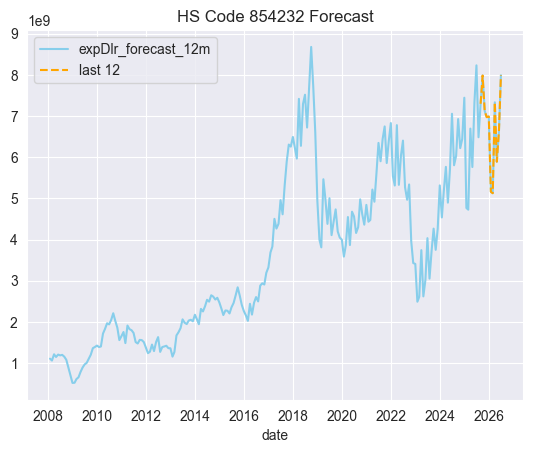

In [42]:
plot_forecast_by_hscode_list(db_info, ['854232'])

In [19]:
trade_pivot_df = pivot_dataframe(trade_data_df,
                 index_col='date',
                 column_col='root_hs_code',
                 indicator_col='indicator',
                 value_col='value',
                 indicator_value='expDlr')

In [32]:
df = fetch_table_data(db_info, "korea_monthly_trade_data_forecast")

# # 피벗 테이블 생성
pivot_df = df.pivot(index='date', columns='root_hs_code', values='final_expDlr_yoy')

# 인덱스가 datetime 형식인지 확인하고 아니면 변환
pivot_df.index = pd.to_datetime(pivot_df.index)

# 2015년 1월 이후 데이터 필터링
export_growth_df = pivot_df[pivot_df.index >= '2015-01-01']
export_growth_df.head(5)

✅ 'korea_monthly_trade_data_forecast' 테이블에서 167220건의 데이터를 가져왔습니다.


root_hs_code,121120,1212,121221,151550,151590,1518,170199,1902,190230,1905,...,903289,9301,9306,9401,940130,940199,940330,940540,950300,970191
date,,,,,,,,,,,,,,,,,,,,,
2015-01-31,-0.108948,0.100859,0.116872,-0.005645,-0.130204,0.094989,-0.353892,0.116712,0.115063,0.198172,...,0.030356,1.019310,0.344745,-0.093890,0.174571,NaN,-0.575347,-0.219685,0.102912,NaN
2015-02-28,0.156236,-0.077734,-0.063664,-0.002820,0.838857,-0.201831,-0.190644,-0.133266,-0.097966,-0.026833,...,-0.125037,24.643200,-0.160094,-0.142610,0.161992,NaN,-0.777212,-0.278868,-0.229565,NaN
2015-03-31,-0.202061,-0.120939,-0.122407,0.976622,1.117820,-0.190439,-0.064670,0.041299,0.021270,0.073835,...,-0.062737,-0.354952,-0.299348,-0.016428,0.038595,NaN,-0.296035,-0.306940,0.200321,NaN
2015-04-30,-0.001842,0.304537,0.315512,1.355790,13.029600,-0.204453,-0.289587,0.076010,0.065558,-0.034662,...,-0.269028,-0.287707,1.462320,-0.077179,0.471033,NaN,-0.150908,-0.316152,0.075530,NaN
2015-05-31,0.142977,-0.122719,-0.110708,0.446745,13.816800,-0.124952,-0.113941,-0.158640,-0.164846,-0.118842,...,-0.132459,0.253862,1.826010,-0.152784,-0.073821,NaN,-0.334684,-0.278774,-0.177853,NaN


In [46]:
df.head(3)

,date,root_hs_code,final_expDlr_yoy,expDlr_forecast_12m
0,2007-01-31,121120,NaN,NaN
1,2007-01-31,151550,NaN,NaN
2,2007-01-31,151590,NaN,NaN


In [47]:
# # 피벗 테이블 생성
export_df = df.pivot(index='date', columns='root_hs_code', values='expDlr_forecast_12m')

# 1. 모든 값이 NaN인 행 제거
export_df_cleaned = export_df.dropna(how='all', axis=0)

# 2. 최근 12개월 데이터 선택
last_12m = export_df_cleaned.tail(12)

# 3. 마지막 달 값이 NaN인 컬럼 제외
valid_columns = last_12m.columns[~last_12m.iloc[-1].isna()]
last_12m_valid = last_12m[valid_columns]

# 4. 등락률 계산 (YoY % 변화율)
returns = (last_12m_valid.iloc[-1] - last_12m_valid.iloc[0]) / last_12m_valid.iloc[0] * 100

# 5. NaN 또는 inf 값 제거
returns = returns.replace([np.inf, -np.inf], np.nan).dropna()

# 6. 내림차순 정렬
returns = returns.sort_values(ascending=False)

# 7. 데이터프레임으로 정리
returns_df = returns.reset_index()
returns_df.columns = ['HS_Code', '12M_YoY_Change(%)']

# 결과 출력
# pd.set_option('display.float_format', '{:.2f}%'.format)
# display(returns_df)


In [48]:
returns_df

,HS_Code,12M_YoY_Change(%)
0,722530,1147.91%
1,382600,936.47%
2,8802,897.10%
3,7110,614.68%
4,853529,383.38%
...,...,...
656,711021,-175.66%
657,700319,-191.44%
658,900290,-409.35%
659,730629,-521.78%


In [54]:
df.pivot(index='date', columns='root_hs_code', values='expDlr_forecast_12m').tail(12)

root_hs_code,121120,1212,121221,151550,151590,1518,170199,1902,190230,1905,...,903289,9301,9306,9401,940130,940199,940330,940540,950300,970191
date,,,,,,,,,,,,,,,,,,,,,
2025-08-31,4471790.00%,40978900.00%,40776000.00%,128641.00%,315478.00%,122708000.00%,15537200.00%,144694000.00%,136275000.00%,38868000.00%,...,78903300.00%,3487630000000.00%,248357000.00%,68481900.00%,NaN,NaN,680306.00%,NaN,6885310.00%,NaN
2025-09-30,5145680.00%,34158400.00%,34049300.00%,174012.00%,477736.00%,136671000.00%,16963100.00%,147738000.00%,140980000.00%,39342100.00%,...,89047300.00%,3760240000000.00%,227598000.00%,74904600.00%,NaN,NaN,217672.00%,NaN,7035880.00%,NaN
2025-10-31,6439780.00%,38117800.00%,37839400.00%,103171.00%,540384.00%,83661600.00%,15764600.00%,154661000.00%,144063000.00%,40811200.00%,...,85598300.00%,3481770000000.00%,91552100.00%,77114300.00%,NaN,NaN,702757.00%,NaN,6729800.00%,NaN
2025-11-30,5998120.00%,34047800.00%,34010900.00%,172938.00%,534275.00%,21237900.00%,17373300.00%,158561000.00%,147690000.00%,43221700.00%,...,85410200.00%,3146360000000.00%,96644900.00%,74223700.00%,NaN,NaN,1014610.00%,NaN,7145590.00%,NaN
2025-12-31,14575900.00%,34706800.00%,34044900.00%,207526.00%,512919.00%,146218000.00%,17121200.00%,151486000.00%,139506000.00%,38628100.00%,...,87900800.00%,3021850000000.00%,257948000.00%,72336800.00%,NaN,NaN,985225.00%,NaN,8520760.00%,NaN
2026-01-31,4107580.00%,52172100.00%,50865400.00%,539686.00%,476604.00%,-61558000.00%,7300760.00%,146382000.00%,138148000.00%,35967400.00%,...,77213200.00%,2262230000000.00%,115381000.00%,64188700.00%,NaN,NaN,682310.00%,NaN,4960810.00%,NaN
2026-02-28,5358390.00%,43436800.00%,41394000.00%,6366380.00%,909700.00%,128485000.00%,5450930.00%,151462000.00%,144357000.00%,37308500.00%,...,83255500.00%,2161860000000.00%,363420000.00%,66849300.00%,NaN,NaN,1203080.00%,NaN,5643460.00%,NaN
2026-03-31,6142320.00%,67240900.00%,66357500.00%,-8882.35%,562228.00%,183471000.00%,6797970.00%,177696000.00%,164534000.00%,42401000.00%,...,87739600.00%,2265110000000.00%,28808000.00%,73476600.00%,NaN,NaN,1012070.00%,NaN,6378850.00%,NaN
2026-04-30,5187780.00%,67276600.00%,65541200.00%,272600.00%,783489.00%,304284000.00%,8363420.00%,180549000.00%,168988000.00%,41769000.00%,...,85883200.00%,2248150000000.00%,501920000.00%,67254900.00%,NaN,NaN,1240920.00%,NaN,6389520.00%,NaN


In [56]:
df = fetch_table_data(db_info, "korea_monthly_trade_data_forecast")
df.tail(12)

✅ 'korea_monthly_trade_data_forecast' 테이블에서 167220건의 데이터를 가져왔습니다.


,date,root_hs_code,final_expDlr_yoy,expDlr_forecast_12m
167208,2026-07-31,903082,0.16%,NaN
167209,2026-07-31,903090,-0.04%,NaN
167210,2026-07-31,9031,0.07%,NaN
167211,2026-07-31,903141,0.32%,NaN
167212,2026-07-31,903149,-0.01%,NaN
167213,2026-07-31,903180,-0.02%,NaN
167214,2026-07-31,903190,-0.05%,NaN
167215,2026-07-31,9032,-0.00%,NaN
167216,2026-07-31,903289,0.09%,NaN
167217,2026-07-31,9301,24564.50%,NaN


In [58]:
df[df['root_hs_code'] == '854232'].tail(12)

,date,root_hs_code,final_expDlr_yoy,expDlr_forecast_12m
159231,2025-08-31,854232,0.21%,7298130000.00%
159953,2025-09-30,854232,0.15%,7983190000.00%
160675,2025-10-31,854232,0.14%,7121290000.00%
161397,2025-11-30,854232,0.08%,6972560000.00%
162119,2025-12-31,854232,-0.06%,6988610000.00%
162841,2026-01-31,854232,0.08%,5160110000.00%
163563,2026-02-28,854232,0.08%,5125820000.00%
164285,2026-03-31,854232,0.10%,7332990000.00%
165007,2026-04-30,854232,0.02%,5890480000.00%
165729,2026-05-31,854232,-0.10%,6621000000.00%
